# UPI Shield AI — Notebook 5: Model Evaluation and Risk Scoring

## Objective

The objective of this notebook is to deeply evaluate the best trained model selected in Notebook 4.

In this notebook, we will:

1. Load the saved best model.
2. Load the processed dataset.
3. Recreate the same train-test split.
4. Evaluate the model on original test data.
5. Analyze confusion matrix, precision, recall, F1-score, and ROC-AUC.
6. Plot ROC curve and Precision-Recall curve.
7. Convert fraud probability into risk score.
8. Test custom transaction examples.
9. Save the final model evaluation report.

This notebook prepares the model for the final Streamlit application.

In [1]:
# ---------------------------------------------------------
# Step 1: Import Required Libraries
# ---------------------------------------------------------
# We import libraries required for:
# 1. Data loading
# 2. Model loading
# 3. Evaluation metrics
# 4. Visualization
# 5. Custom transaction testing

import os
import json
import joblib
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ---------------------------------------------------------
# Step 2: Mount Google Drive
# ---------------------------------------------------------
# We mount Google Drive to access saved model, processed data,
# reports, and screenshots.

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [3]:
# ---------------------------------------------------------
# Step 3: Define Project Paths
# ---------------------------------------------------------
# These paths are used to load processed data, saved model,
# and save evaluation outputs.

BASE_DIR = "/content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring"

PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
SCREENSHOTS_DIR = os.path.join(BASE_DIR, "screenshots")

PROCESSED_DATA_PATH = os.path.join(PROCESSED_DATA_DIR, "processed_fraud_data.parquet")
FEATURE_LIST_PATH = os.path.join(PROCESSED_DATA_DIR, "feature_list.json")
BEST_MODEL_PATH = os.path.join(MODELS_DIR, "best_model.pkl")

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

print("Processed Data Path:", PROCESSED_DATA_PATH)
print("Feature Metadata Path:", FEATURE_LIST_PATH)
print("Best Model Path:", BEST_MODEL_PATH)
print("Reports Directory:", REPORTS_DIR)
print("Screenshots Directory:", SCREENSHOTS_DIR)

Processed Data Path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/data/processed/processed_fraud_data.parquet
Feature Metadata Path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/data/processed/feature_list.json
Best Model Path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/models/best_model.pkl
Reports Directory: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports
Screenshots Directory: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/screenshots


In [4]:
# ---------------------------------------------------------
# Step 4: Check Required Files
# ---------------------------------------------------------
# We check whether all required files from previous notebooks exist.

required_files = {
    "Processed Dataset": PROCESSED_DATA_PATH,
    "Feature Metadata": FEATURE_LIST_PATH,
    "Best Model": BEST_MODEL_PATH
}

for file_name, file_path in required_files.items():
    if os.path.exists(file_path):
        print(f"{file_name} found.")
    else:
        print(f"{file_name} NOT found. Please check previous notebook outputs.")

Processed Dataset found.
Feature Metadata found.
Best Model found.


In [5]:
# ---------------------------------------------------------
# Step 5: Load Processed Dataset
# ---------------------------------------------------------
# We load the processed Parquet dataset created in Notebook 3.

df = pd.read_parquet(PROCESSED_DATA_PATH)

print("Processed dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Processed dataset loaded successfully.
Shape: (208213, 25)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,errorBalanceOrig,errorBalanceDest,isZeroBalanceAfterTransaction,isHighAmount,hourOfDay,isHighRiskType,logAmount,logBalanceDiffOrig,logBalanceDiffDest,logErrorBalanceOrig,logErrorBalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,349,65487.9883,141478.0000,75990.0078,0.0000,0.0000,0,65487.9922,0.0000,0.0078,65487.9883,0,0,13,0,11.0896,11.0896,0.0000,0.0078,11.0896,0,0,0,1,0
1,257,299940.0312,0.0000,0.0000,502460.1250,802400.1250,0,0.0000,299940.0000,-299940.0312,0.0000,1,0,17,1,12.6113,0.0000,12.6113,12.6113,0.0000,0,1,0,0,0
2,281,16878.8594,17579.6504,700.7900,0.0000,0.0000,0,16878.8613,0.0000,0.0010,16878.8594,0,0,17,0,9.7339,9.7339,0.0000,0.0010,9.7339,0,0,0,1,0
3,42,132800.6250,0.0000,0.0000,638717.3125,771517.9375,0,0.0000,132800.6250,-132800.6250,0.0000,1,0,18,1,11.7966,0.0000,11.7966,11.7966,0.0000,0,1,0,0,0
4,15,238788.1562,0.0000,0.0000,672467.0625,911255.2500,0,0.0000,238788.1875,-238788.1562,0.0000,1,0,15,1,12.3833,0.0000,12.3833,12.3833,0.0000,0,1,0,0,0


In [6]:
# ---------------------------------------------------------
# Step 6: Load Feature Metadata
# ---------------------------------------------------------
# Feature metadata contains final feature list, target column,
# high amount threshold, and other project settings.

with open(FEATURE_LIST_PATH, "r") as file:
    feature_metadata = json.load(file)

features = feature_metadata["features"]
target = feature_metadata["target"]
high_amount_threshold = feature_metadata["high_amount_threshold"]
high_risk_types = feature_metadata["high_risk_types"]

print("Feature metadata loaded successfully.")
print("Target column:", target)
print("Total features:", len(features))
print("High amount threshold:", high_amount_threshold)
print("High risk transaction types:", high_risk_types)

Feature metadata loaded successfully.
Target column: isFraud
Total features: 24
High amount threshold: 652597.4249999999
High risk transaction types: ['TRANSFER', 'CASH_OUT']


In [7]:
# ---------------------------------------------------------
# Step 7: Load Best Model
# ---------------------------------------------------------
# We load the best model saved in Notebook 4.
# The model bundle contains:
# 1. Model object
# 2. Scaler if required
# 3. Feature list
# 4. Model metadata

best_model_bundle = joblib.load(BEST_MODEL_PATH)

best_model_name = best_model_bundle["model_name"]
best_model = best_model_bundle["model"]
best_scaler = best_model_bundle["scaler"]
requires_scaling = best_model_bundle["requires_scaling"]

print("Best model loaded successfully.")
print("Best model name:", best_model_name)
print("Requires scaling:", requires_scaling)
print("Number of features in model:", len(best_model_bundle["features"]))

Best model loaded successfully.
Best model name: Decision Tree
Requires scaling: False
Number of features in model: 24


In [8]:
# ---------------------------------------------------------
# Step 8: Basic Dataset Check
# ---------------------------------------------------------
# We check target distribution before recreating the test split.

print("Dataset shape:", df.shape)

print("\nTarget distribution:")
print(df[target].value_counts())

print("\nTarget percentage:")
print(df[target].value_counts(normalize=True) * 100)

print("\nMissing values:", df.isnull().sum().sum())

Dataset shape: (208213, 25)

Target distribution:
isFraud
0    200000
1      8213
Name: count, dtype: int64

Target percentage:
isFraud
0   96.0555
1    3.9445
Name: proportion, dtype: float64

Missing values: 0


In [9]:
# ---------------------------------------------------------
# Step 9: Separate Features and Target
# ---------------------------------------------------------
# X contains input features.
# y contains target labels.

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (208213, 24)
y shape: (208213,)


In [10]:
# ---------------------------------------------------------
# Step 10: Recreate Train-Test Split
# ---------------------------------------------------------
# We recreate the same train-test split used in Notebook 4.
#
# random_state=42 and stratify=y are important so that
# the split remains consistent.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split recreated successfully.")

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTest target percentage:")
print(y_test.value_counts(normalize=True) * 100)

Train-test split recreated successfully.

X_test shape: (41643, 24)
y_test shape: (41643,)

Test target distribution:
isFraud
0    40000
1     1643
Name: count, dtype: int64

Test target percentage:
isFraud
0   96.0546
1    3.9454
Name: proportion, dtype: float64


In [11]:
# ---------------------------------------------------------
# Step 11: Free Extra Memory
# ---------------------------------------------------------
# We delete unnecessary large variables to keep Colab stable.

del df
del X
del y
del X_train
del y_train

import gc
gc.collect()

print("Unused variables deleted from memory.")

Unused variables deleted from memory.


In [13]:
# ---------------------------------------------------------
# Step 12: Prepare Test Data for Best Model
# ---------------------------------------------------------
# If the best model requires scaling, we transform X_test
# using the saved scaler.
#
# If not, we use X_test directly.

if requires_scaling:
    X_test_model = best_scaler.transform(X_test)
    print("Test data scaled successfully.")
else:
    X_test_model = X_test
    print("Best model does not require scaling.")

print("Test data prepared for prediction.")

Best model does not require scaling.
Test data prepared for prediction.


In [14]:
# ---------------------------------------------------------
# Step 13: Generate Predictions
# ---------------------------------------------------------
# We generate class predictions and fraud probabilities.

y_pred = best_model.predict(X_test_model)

if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test_model)[:, 1]
else:
    y_proba = None

print("Predictions generated successfully.")

print("First 10 predictions:")
print(y_pred[:10])

if y_proba is not None:
    print("\nFirst 10 fraud probabilities:")
    print(y_proba[:10])

Predictions generated successfully.
First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 fraud probabilities:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.00068587 0.        ]


In [15]:
# ---------------------------------------------------------
# Step 14: Calculate Evaluation Metrics
# ---------------------------------------------------------
# We calculate all important fraud detection metrics.

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

if y_proba is not None:
    roc_auc = roc_auc_score(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
else:
    roc_auc = np.nan
    avg_precision = np.nan

evaluation_metrics = {
    "Model": best_model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC AUC": roc_auc,
    "Average Precision": avg_precision
}

evaluation_metrics_df = pd.DataFrame([evaluation_metrics])

evaluation_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Average Precision
0,Decision Tree,0.9994,0.9868,0.9976,0.9921,0.9989,0.9972


## Metric Interpretation

For this project, accuracy is not enough because fraud data is imbalanced.

Important metrics:

- **Precision**: Out of all transactions predicted as fraud, how many were actually fraud.
- **Recall**: Out of all actual fraud transactions, how many were correctly detected.
- **F1-score**: Balance between precision and recall.
- **ROC-AUC**: Ability of the model to separate fraud and normal transactions.
- **Average Precision**: Useful metric for imbalanced classification problems.

For fraud detection, recall is very important because missing fraud transactions can be costly.

In [16]:
# ---------------------------------------------------------
# Step 15: Classification Report
# ---------------------------------------------------------
# This gives class-wise precision, recall, and F1-score.

report = classification_report(
    y_test,
    y_pred,
    target_names=["Normal Transaction", "Fraud Transaction"]
)

print(report)

                    precision    recall  f1-score   support

Normal Transaction       1.00      1.00      1.00     40000
 Fraud Transaction       0.99      1.00      0.99      1643

          accuracy                           1.00     41643
         macro avg       0.99      1.00      1.00     41643
      weighted avg       1.00      1.00      1.00     41643



In [17]:
# ---------------------------------------------------------
# Step 16: Confusion Matrix Values
# ---------------------------------------------------------
# Confusion matrix shows:
#
# TN = Normal correctly predicted as normal
# FP = Normal wrongly predicted as fraud
# FN = Fraud wrongly predicted as normal
# TP = Fraud correctly predicted as fraud

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix:
[[39978    22]
 [    4  1639]]

True Negatives: 39978
False Positives: 22
False Negatives: 4
True Positives: 1639


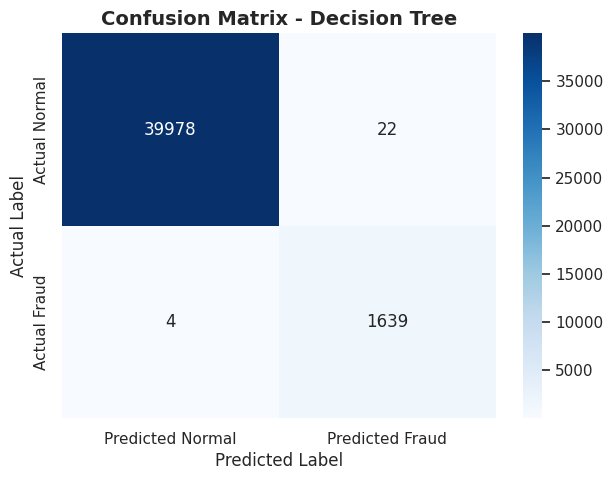

Confusion matrix image saved at:
/content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/screenshots/confusion_matrix_best_model.png


In [18]:
# ---------------------------------------------------------
# Step 17: Confusion Matrix Plot
# ---------------------------------------------------------
# We visualize the confusion matrix for better understanding.

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Fraud"],
    yticklabels=["Actual Normal", "Actual Fraud"]
)

plt.title(f"Confusion Matrix - {best_model_name}", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

confusion_matrix_path = os.path.join(SCREENSHOTS_DIR, "confusion_matrix_best_model.png")
plt.savefig(confusion_matrix_path, bbox_inches="tight", dpi=300)

plt.show()

print("Confusion matrix image saved at:")
print(confusion_matrix_path)

In [19]:
# ---------------------------------------------------------
# Step 18: Error Analysis Summary
# ---------------------------------------------------------
# We calculate false positive rate and false negative rate.

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

error_summary = pd.DataFrame({
    "Metric": [
        "False Positive Rate",
        "False Negative Rate",
        "Fraud Detection Rate / Recall",
        "Normal Detection Rate / Specificity"
    ],
    "Value": [
        false_positive_rate,
        false_negative_rate,
        recall,
        tn / (tn + fp)
    ]
})

error_summary

,Metric,Value
0,False Positive Rate,0.0006
1,False Negative Rate,0.0024
2,Fraud Detection Rate / Recall,0.9976
3,Normal Detection Rate / Specificity,0.9994


## Confusion Matrix Observation

In fraud detection:

- **False Negative** is very dangerous because it means an actual fraud transaction was predicted as normal.
- **False Positive** means a normal transaction was wrongly flagged as fraud.

For this project, we prefer reducing false negatives while keeping false positives under control.

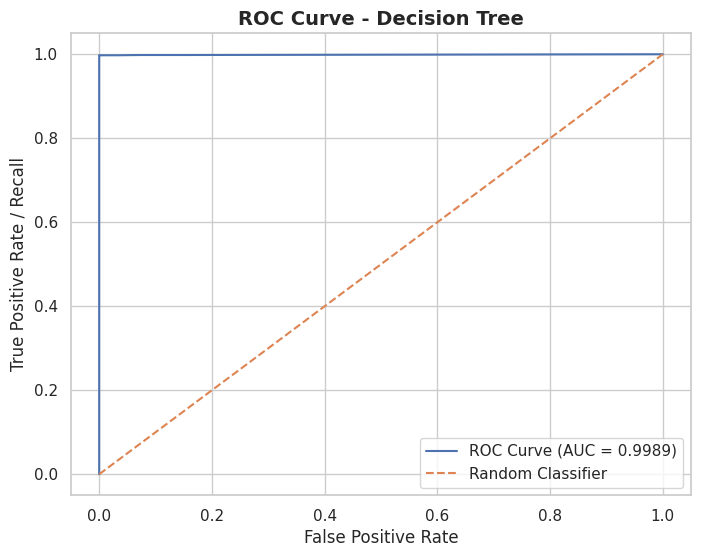

ROC curve image saved at:
/content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/screenshots/roc_curve_best_model.png


In [20]:
# ---------------------------------------------------------
# Step 19: ROC Curve
# ---------------------------------------------------------
# ROC curve shows how well the model separates fraud and
# normal transactions at different thresholds.

if y_proba is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    plt.figure(figsize=(8, 6))

    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

    plt.title(f"ROC Curve - {best_model_name}", fontsize=14, fontweight="bold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.legend()

    roc_curve_path = os.path.join(SCREENSHOTS_DIR, "roc_curve_best_model.png")
    plt.savefig(roc_curve_path, bbox_inches="tight", dpi=300)

    plt.show()

    print("ROC curve image saved at:")
    print(roc_curve_path)
else:
    print("ROC curve cannot be plotted because probability scores are not available.")

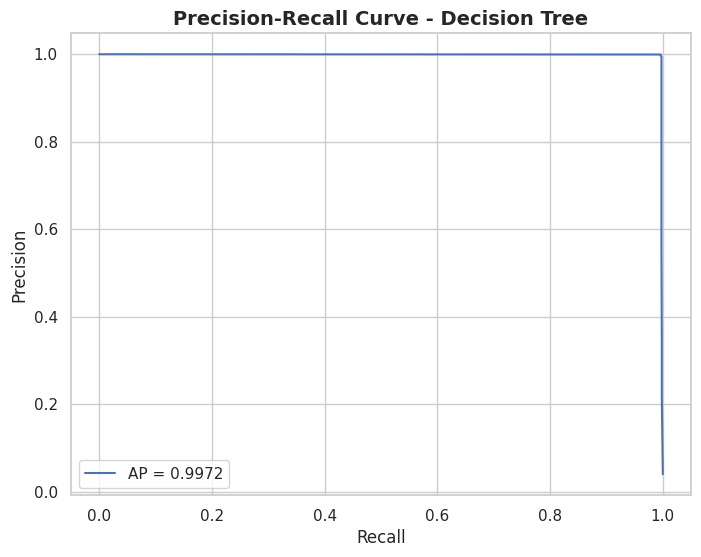

Precision-Recall curve image saved at:
/content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/screenshots/precision_recall_curve_best_model.png


In [21]:
# ---------------------------------------------------------
# Step 20: Precision-Recall Curve
# ---------------------------------------------------------
# Precision-Recall curve is very useful for imbalanced datasets
# like fraud detection.

if y_proba is not None:
    precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(8, 6))

    plt.plot(recalls, precisions, label=f"AP = {avg_precision:.4f}")

    plt.title(f"Precision-Recall Curve - {best_model_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    pr_curve_path = os.path.join(SCREENSHOTS_DIR, "precision_recall_curve_best_model.png")
    plt.savefig(pr_curve_path, bbox_inches="tight", dpi=300)

    plt.show()

    print("Precision-Recall curve image saved at:")
    print(pr_curve_path)
else:
    print("Precision-Recall curve cannot be plotted because probability scores are not available.")

In [22]:
# ---------------------------------------------------------
# Step 21: Create Prediction Results DataFrame
# ---------------------------------------------------------
# We create a dataframe containing actual labels, predicted labels,
# fraud probabilities, and risk scores.

prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

if y_proba is not None:
    prediction_results["Fraud Probability"] = y_proba
    prediction_results["Risk Score"] = (y_proba * 100).round(2)
else:
    prediction_results["Fraud Probability"] = np.nan
    prediction_results["Risk Score"] = np.nan

prediction_results["Actual Label"] = prediction_results["Actual"].map({
    0: "Normal",
    1: "Fraud"
})

prediction_results["Predicted Label"] = prediction_results["Predicted"].map({
    0: "Normal",
    1: "Fraud"
})

prediction_results.head(10)

,Actual,Predicted,Fraud Probability,Risk Score,Actual Label,Predicted Label
0,0,0,0.0000,0.0000,Normal,Normal
1,0,0,0.0000,0.0000,Normal,Normal
2,0,0,0.0000,0.0000,Normal,Normal
3,0,0,0.0000,0.0000,Normal,Normal
4,0,0,0.0000,0.0000,Normal,Normal
5,0,0,0.0000,0.0000,Normal,Normal
6,0,0,0.0000,0.0000,Normal,Normal
7,0,0,0.0000,0.0000,Normal,Normal
8,0,0,0.0007,0.0700,Normal,Normal
9,0,0,0.0000,0.0000,Normal,Normal


In [24]:
# ---------------------------------------------------------
# Step 22: Create Risk Level Function
# ---------------------------------------------------------
# We convert fraud probability/risk score into risk level.
#
# 0-30   = Low Risk
# 31-70  = Medium Risk
# 71-100 = High Risk

def get_risk_level(risk_score):
    """
    Converts numerical risk score into risk level.
    """
    if risk_score <= 30:
        return "No/Low Risk"
    elif risk_score <= 70:
        return "Medium Risk"
    else:
        return "High Risk"

prediction_results["Risk Level"] = prediction_results["Risk Score"].apply(get_risk_level)

prediction_results.head(10)

,Actual,Predicted,Fraud Probability,Risk Score,Actual Label,Predicted Label,Risk Level
0,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
1,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
2,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
3,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
4,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
5,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
6,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
7,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk
8,0,0,0.0007,0.0700,Normal,Normal,No/Low Risk
9,0,0,0.0000,0.0000,Normal,Normal,No/Low Risk


In [25]:
# ---------------------------------------------------------
# Step 23: Risk Level Distribution
# ---------------------------------------------------------
# This shows how many test transactions fall into each risk level.

risk_level_distribution = prediction_results["Risk Level"].value_counts()

risk_level_distribution

,count
Risk Level,
No/Low Risk,39972
High Risk,1650
Medium Risk,21


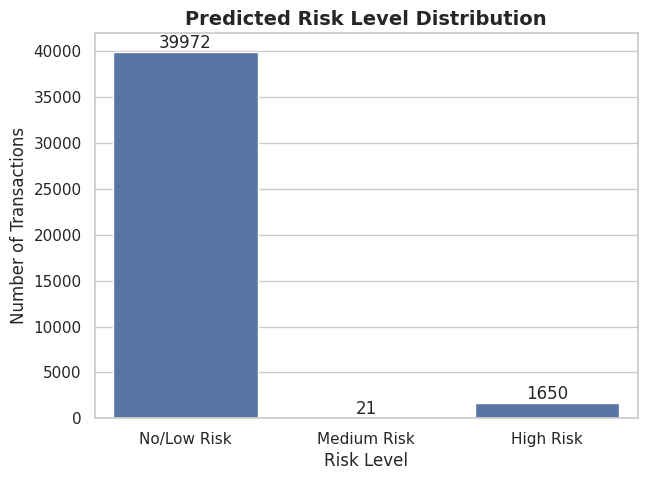

Risk level distribution image saved at:
/content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/screenshots/risk_level_distribution.png


In [28]:
# ---------------------------------------------------------
# Step 24: Risk Level Distribution Plot
# ---------------------------------------------------------
# We visualize the distribution of predicted risk levels.

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=prediction_results,
    x="Risk Level",
    order=["No/Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Predicted Risk Level Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

risk_level_path = os.path.join(SCREENSHOTS_DIR, "risk_level_distribution.png")
plt.savefig(risk_level_path, bbox_inches="tight", dpi=300)

plt.show()

print("Risk level distribution image saved at:")
print(risk_level_path)

In [29]:
# ---------------------------------------------------------
# Step 25: Evaluate Different Probability Thresholds
# ---------------------------------------------------------
# By default, threshold is 0.5.
# If probability >= 0.5, prediction = Fraud.
#
# In fraud detection, we may test lower thresholds to improve recall.

def evaluate_threshold(y_true, probabilities, threshold):
    """
    Evaluates model performance at a custom probability threshold.
    """
    y_pred_threshold = (probabilities >= threshold).astype(int)

    cm_threshold = confusion_matrix(y_true, y_pred_threshold)
    tn_t, fp_t, fn_t, tp_t = cm_threshold.ravel()

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred_threshold),
        "Precision": precision_score(y_true, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_true, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred_threshold, zero_division=0),
        "False Positives": fp_t,
        "False Negatives": fn_t,
        "True Positives": tp_t,
        "True Negatives": tn_t
    }

if y_proba is not None:
    thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

    threshold_results = []

    for threshold in thresholds_to_test:
        threshold_results.append(
            evaluate_threshold(y_test, y_proba, threshold)
        )

    threshold_results_df = pd.DataFrame(threshold_results)

    threshold_results_df
else:
    print("Threshold analysis cannot be done because probabilities are not available.")

In [30]:
# ---------------------------------------------------------
# Step 26: Save Threshold Analysis
# ---------------------------------------------------------
# We save threshold comparison for future reference.

if y_proba is not None:
    THRESHOLD_REPORT_PATH = os.path.join(REPORTS_DIR, "05_threshold_analysis.csv")
    threshold_results_df.to_csv(THRESHOLD_REPORT_PATH, index=False)

    print("Threshold analysis saved successfully.")
    print("Saved path:", THRESHOLD_REPORT_PATH)

Threshold analysis saved successfully.
Saved path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports/05_threshold_analysis.csv


## Threshold Analysis Observation

The default classification threshold is 0.5.

For fraud detection, changing the threshold can affect recall and precision.

- Lower threshold usually increases recall but may increase false positives.
- Higher threshold usually increases precision but may miss more fraud cases.

For this project, we will keep the default threshold initially, but the Streamlit app will still display fraud probability and risk score to support decision-making.

In [31]:
# ---------------------------------------------------------
# Step 27: Create Feature Preparation Function
# ---------------------------------------------------------
# This function takes raw transaction input and creates the
# exact same features used during model training.
#
# It is important because the Streamlit app will also use
# similar logic.

def prepare_transaction_features(
    step,
    transaction_type,
    amount,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest
):
    """
    Prepares a single transaction for prediction.

    Parameters:
    step: Transaction time step
    transaction_type: PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT
    amount: Transaction amount
    oldbalanceOrg: Sender old balance
    newbalanceOrig: Sender new balance
    oldbalanceDest: Receiver old balance
    newbalanceDest: Receiver new balance

    Returns:
    DataFrame with same feature columns used during model training
    """

    data = {
        "step": step,
        "amount": amount,
        "oldbalanceOrg": oldbalanceOrg,
        "newbalanceOrig": newbalanceOrig,
        "oldbalanceDest": oldbalanceDest,
        "newbalanceDest": newbalanceDest
    }

    input_df = pd.DataFrame([data])

    # Create engineered features
    input_df["balanceDiffOrig"] = input_df["oldbalanceOrg"] - input_df["newbalanceOrig"]
    input_df["balanceDiffDest"] = input_df["newbalanceDest"] - input_df["oldbalanceDest"]

    input_df["errorBalanceOrig"] = (
        input_df["oldbalanceOrg"] - input_df["amount"] - input_df["newbalanceOrig"]
    )

    input_df["errorBalanceDest"] = (
        input_df["oldbalanceDest"] + input_df["amount"] - input_df["newbalanceDest"]
    )

    input_df["isZeroBalanceAfterTransaction"] = np.where(
        input_df["newbalanceOrig"] == 0,
        1,
        0
    )

    input_df["isHighAmount"] = np.where(
        input_df["amount"] >= high_amount_threshold,
        1,
        0
    )

    input_df["isHighRiskType"] = np.where(
        transaction_type in high_risk_types,
        1,
        0
    )

    input_df["hourOfDay"] = input_df["step"] % 24

    input_df["logAmount"] = np.log1p(input_df["amount"])
    input_df["logBalanceDiffOrig"] = np.log1p(np.abs(input_df["balanceDiffOrig"]))
    input_df["logBalanceDiffDest"] = np.log1p(np.abs(input_df["balanceDiffDest"]))
    input_df["logErrorBalanceOrig"] = np.log1p(np.abs(input_df["errorBalanceOrig"]))
    input_df["logErrorBalanceDest"] = np.log1p(np.abs(input_df["errorBalanceDest"]))

    # Create transaction type one-hot columns
    transaction_types = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]

    for t_type in transaction_types:
        input_df[f"type_{t_type}"] = 1 if transaction_type == t_type else 0

    # Ensure all required features exist
    for feature in features:
        if feature not in input_df.columns:
            input_df[feature] = 0

    # Reorder columns according to training feature order
    input_df = input_df[features]

    return input_df

In [32]:
# ---------------------------------------------------------
# Step 28: Create Risk Reason Function
# ---------------------------------------------------------
# This function gives human-readable reasons for risk score.
# This makes our project more explainable and app-friendly.

def generate_risk_reasons(
    transaction_type,
    amount,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest,
    risk_score
):
    """
    Generates rule-based explanation for transaction risk.
    """

    reasons = []

    balance_diff_orig = oldbalanceOrg - newbalanceOrig
    balance_diff_dest = newbalanceDest - oldbalanceDest

    error_orig = oldbalanceOrg - amount - newbalanceOrig
    error_dest = oldbalanceDest + amount - newbalanceDest

    if transaction_type in high_risk_types:
        reasons.append(f"{transaction_type} is considered a higher-risk transaction type.")

    if amount >= high_amount_threshold:
        reasons.append("Transaction amount is higher than the high amount threshold.")

    if newbalanceOrig == 0 and oldbalanceOrg > 0:
        reasons.append("Sender balance became zero after the transaction.")

    if abs(error_orig) > 0:
        reasons.append("Sender balance movement does not perfectly match the transaction amount.")

    if abs(error_dest) > 0:
        reasons.append("Receiver balance movement does not perfectly match the transaction amount.")

    if balance_diff_orig >= amount:
        reasons.append("Sender balance reduction is equal to or greater than transaction amount.")

    if risk_score > 70:
        reasons.append("Model predicted high fraud probability for this transaction.")
    elif risk_score > 30:
        reasons.append("Model predicted medium fraud probability for this transaction.")
    else:
        reasons.append("Model predicted low fraud probability for this transaction.")

    if len(reasons) == 0:
        reasons.append("No major suspicious rule-based pattern detected.")

    return reasons

In [33]:
# ---------------------------------------------------------
# Step 29: Create Full Transaction Prediction Function
# ---------------------------------------------------------
# This function combines:
# 1. Feature preparation
# 2. Model prediction
# 3. Fraud probability
# 4. Risk score
# 5. Risk level
# 6. Reasons
# 7. Recommended action

def predict_transaction_risk(
    step,
    transaction_type,
    amount,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest
):
    """
    Predicts transaction risk using the trained best model.
    """

    input_features = prepare_transaction_features(
        step=step,
        transaction_type=transaction_type,
        amount=amount,
        oldbalanceOrg=oldbalanceOrg,
        newbalanceOrig=newbalanceOrig,
        oldbalanceDest=oldbalanceDest,
        newbalanceDest=newbalanceDest
    )

    if requires_scaling:
        input_model = best_scaler.transform(input_features)
    else:
        input_model = input_features

    prediction = best_model.predict(input_model)[0]

    if hasattr(best_model, "predict_proba"):
        fraud_probability = best_model.predict_proba(input_model)[0][1]
    else:
        fraud_probability = float(prediction)

    risk_score = round(fraud_probability * 100, 2)
    risk_level = get_risk_level(risk_score)

    if risk_level == "Low Risk":
        recommended_action = "Allow transaction."
    elif risk_level == "Medium Risk":
        recommended_action = "Ask for additional verification."
    else:
        recommended_action = "Hold transaction and perform manual verification."

    reasons = generate_risk_reasons(
        transaction_type=transaction_type,
        amount=amount,
        oldbalanceOrg=oldbalanceOrg,
        newbalanceOrig=newbalanceOrig,
        oldbalanceDest=oldbalanceDest,
        newbalanceDest=newbalanceDest,
        risk_score=risk_score
    )

    result = {
        "Prediction": "Suspicious / Fraud" if prediction == 1 else "Normal / Safe",
        "Fraud Probability": fraud_probability,
        "Risk Score": risk_score,
        "Risk Level": risk_level,
        "Recommended Action": recommended_action,
        "Reasons": reasons
    }

    return result

In [37]:
# ---------------------------------------------------------
# Step 30: Test Normal Transaction
# ---------------------------------------------------------
# This is a low-risk example.

normal_transaction_result = predict_transaction_risk(
    step=10,
    transaction_type="PAYMENT",
    amount=2500,
    oldbalanceOrg=50000,
    newbalanceOrig=47500,
    oldbalanceDest=10000,
    newbalanceDest=12500
)

normal_transaction_result

{'Prediction': 'Normal / Safe',
 'Fraud Probability': np.float64(0.0),
 'Risk Score': np.float64(0.0),
 'Risk Level': 'No/Low Risk',
 'Recommended Action': 'Hold transaction and perform manual verification.',
 'Reasons': ['Sender balance reduction is equal to or greater than transaction amount.',
  'Model predicted low fraud probability for this transaction.']}

In [38]:
  # ---------------------------------------------------------
# Step 31: Display Normal Transaction Result
# ---------------------------------------------------------
# We print result in readable format.

print("Normal Transaction Test Result")
print("=" * 50)

for key, value in normal_transaction_result.items():
    if key != "Reasons":
        print(f"{key}: {value}")

print("\nReasons:")
for reason in normal_transaction_result["Reasons"]:
    print("-", reason)

Normal Transaction Test Result
Prediction: Normal / Safe
Fraud Probability: 0.0
Risk Score: 0.0
Risk Level: No/Low Risk
Recommended Action: Hold transaction and perform manual verification.

Reasons:
- Sender balance reduction is equal to or greater than transaction amount.
- Model predicted low fraud probability for this transaction.


In [39]:
# ---------------------------------------------------------
# Step 32: Test Suspicious High-Risk Transaction
# ---------------------------------------------------------
# This example has high amount, TRANSFER type, and sender
# balance becoming zero.

suspicious_transaction_result = predict_transaction_risk(
    step=25,
    transaction_type="TRANSFER",
    amount=95000,
    oldbalanceOrg=95000,
    newbalanceOrig=0,
    oldbalanceDest=2000,
    newbalanceDest=97000
)

suspicious_transaction_result

{'Prediction': 'Suspicious / Fraud',
 'Fraud Probability': np.float64(1.0),
 'Risk Score': np.float64(100.0),
 'Risk Level': 'High Risk',
 'Recommended Action': 'Hold transaction and perform manual verification.',
 'Reasons': ['TRANSFER is considered a higher-risk transaction type.',
  'Sender balance became zero after the transaction.',
  'Sender balance reduction is equal to or greater than transaction amount.',
  'Model predicted high fraud probability for this transaction.']}

In [40]:
# ---------------------------------------------------------
# Step 33: Display Suspicious Transaction Result
# ---------------------------------------------------------
# We print result in readable format.

print("Suspicious Transaction Test Result")
print("=" * 50)

for key, value in suspicious_transaction_result.items():
    if key != "Reasons":
        print(f"{key}: {value}")

print("\nReasons:")
for reason in suspicious_transaction_result["Reasons"]:
    print("-", reason)

Suspicious Transaction Test Result
Prediction: Suspicious / Fraud
Fraud Probability: 1.0
Risk Score: 100.0
Risk Level: High Risk
Recommended Action: Hold transaction and perform manual verification.

Reasons:
- TRANSFER is considered a higher-risk transaction type.
- Sender balance became zero after the transaction.
- Sender balance reduction is equal to or greater than transaction amount.
- Model predicted high fraud probability for this transaction.


In [41]:
# ---------------------------------------------------------
# Step 34: Test Medium Risk Transaction
# ---------------------------------------------------------
# This example has moderate amount and high-risk transaction type.

medium_transaction_result = predict_transaction_risk(
    step=48,
    transaction_type="CASH_OUT",
    amount=35000,
    oldbalanceOrg=80000,
    newbalanceOrig=45000,
    oldbalanceDest=5000,
    newbalanceDest=40000
)

medium_transaction_result

{'Prediction': 'Normal / Safe',
 'Fraud Probability': np.float64(0.0),
 'Risk Score': np.float64(0.0),
 'Risk Level': 'No/Low Risk',
 'Recommended Action': 'Hold transaction and perform manual verification.',
 'Reasons': ['CASH_OUT is considered a higher-risk transaction type.',
  'Sender balance reduction is equal to or greater than transaction amount.',
  'Model predicted low fraud probability for this transaction.']}

In [42]:
# ---------------------------------------------------------
# Step 35: Display Medium Risk Transaction Result
# ---------------------------------------------------------
# We print result in readable format.

print("Medium Risk Transaction Test Result")
print("=" * 50)

for key, value in medium_transaction_result.items():
    if key != "Reasons":
        print(f"{key}: {value}")

print("\nReasons:")
for reason in medium_transaction_result["Reasons"]:
    print("-", reason)

Medium Risk Transaction Test Result
Prediction: Normal / Safe
Fraud Probability: 0.0
Risk Score: 0.0
Risk Level: No/Low Risk
Recommended Action: Hold transaction and perform manual verification.

Reasons:
- CASH_OUT is considered a higher-risk transaction type.
- Sender balance reduction is equal to or greater than transaction amount.
- Model predicted low fraud probability for this transaction.


In [43]:
# ---------------------------------------------------------
# Step 36: Create Custom Testing Summary Table
# ---------------------------------------------------------
# We summarize all manual transaction tests in one table.

custom_test_results = pd.DataFrame([
    {
        "Test Case": "Normal Transaction",
        "Prediction": normal_transaction_result["Prediction"],
        "Fraud Probability": normal_transaction_result["Fraud Probability"],
        "Risk Score": normal_transaction_result["Risk Score"],
        "Risk Level": normal_transaction_result["Risk Level"],
        "Recommended Action": normal_transaction_result["Recommended Action"]
    },
    {
        "Test Case": "Suspicious Transaction",
        "Prediction": suspicious_transaction_result["Prediction"],
        "Fraud Probability": suspicious_transaction_result["Fraud Probability"],
        "Risk Score": suspicious_transaction_result["Risk Score"],
        "Risk Level": suspicious_transaction_result["Risk Level"],
        "Recommended Action": suspicious_transaction_result["Recommended Action"]
    },
    {
        "Test Case": "Medium Risk Transaction",
        "Prediction": medium_transaction_result["Prediction"],
        "Fraud Probability": medium_transaction_result["Fraud Probability"],
        "Risk Score": medium_transaction_result["Risk Score"],
        "Risk Level": medium_transaction_result["Risk Level"],
        "Recommended Action": medium_transaction_result["Recommended Action"]
    }
])

custom_test_results

,Test Case,Prediction,Fraud Probability,Risk Score,Risk Level,Recommended Action
0,Normal Transaction,Normal / Safe,0.0000,0.0000,No/Low Risk,Hold transaction and perform manual verification.
1,Suspicious Transaction,Suspicious / Fraud,1.0000,100.0000,High Risk,Hold transaction and perform manual verification.
2,Medium Risk Transaction,Normal / Safe,0.0000,0.0000,No/Low Risk,Hold transaction and perform manual verification.


In [44]:
# ---------------------------------------------------------
# Step 37: Save Custom Test Results
# ---------------------------------------------------------
# We save manual testing results for project documentation.

CUSTOM_TEST_RESULTS_PATH = os.path.join(REPORTS_DIR, "05_custom_transaction_tests.csv")

custom_test_results.to_csv(CUSTOM_TEST_RESULTS_PATH, index=False)

print("Custom transaction test results saved successfully.")
print("Saved path:", CUSTOM_TEST_RESULTS_PATH)

Custom transaction test results saved successfully.
Saved path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports/05_custom_transaction_tests.csv


In [45]:
# ---------------------------------------------------------
# Step 38: Extract Feature Importance
# ---------------------------------------------------------
# If the best model supports feature importance, we extract it.
# This helps explain which features influenced model decisions.

if hasattr(best_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("Feature importance extracted successfully.")
    display(feature_importance_df.head(15))
else:
    feature_importance_df = None
    print("This model does not provide feature_importances_.")

Feature importance extracted successfully.


,Feature,Importance
17,logErrorBalanceOrig,0.7048
3,newbalanceOrig,0.2555
9,errorBalanceDest,0.0237
18,logErrorBalanceDest,0.0095
15,logBalanceDiffOrig,0.0018
8,errorBalanceOrig,0.0016
0,step,0.0008
2,oldbalanceOrg,0.0008
4,oldbalanceDest,0.0004
7,balanceDiffDest,0.0003


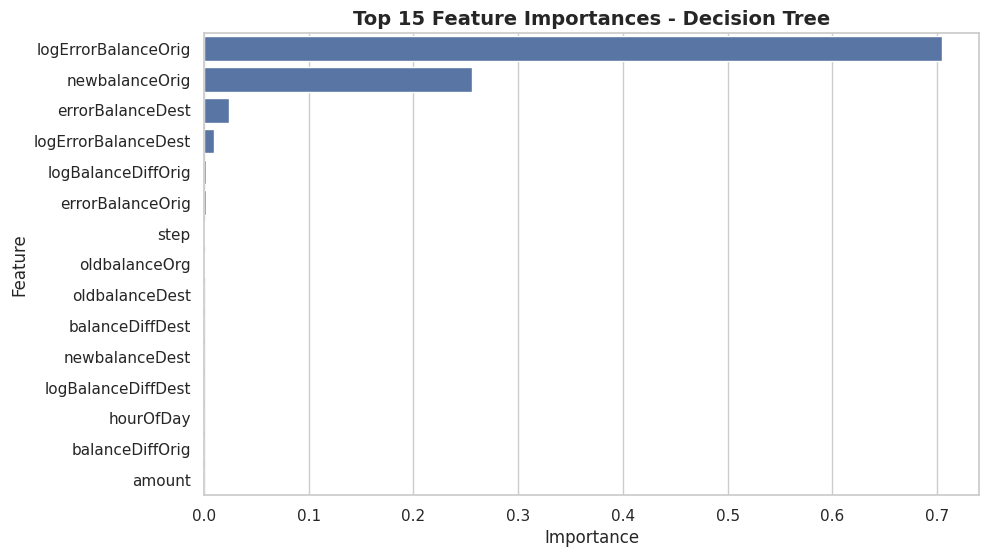

Feature importance plot saved at:
/content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/screenshots/feature_importance_best_model.png


In [46]:
# ---------------------------------------------------------
# Step 39: Feature Importance Plot
# ---------------------------------------------------------
# We plot the top 15 most important features.

if feature_importance_df is not None:
    top_features = feature_importance_df.head(15)

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top 15 Feature Importances - {best_model_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    feature_importance_path = os.path.join(SCREENSHOTS_DIR, "feature_importance_best_model.png")
    plt.savefig(feature_importance_path, bbox_inches="tight", dpi=300)

    plt.show()

    print("Feature importance plot saved at:")
    print(feature_importance_path)
else:
    print("Feature importance plot skipped.")

In [47]:
# ---------------------------------------------------------
# Step 40: Save Feature Importance
# ---------------------------------------------------------
# We save feature importance as CSV if available.

if feature_importance_df is not None:
    FEATURE_IMPORTANCE_PATH = os.path.join(REPORTS_DIR, "05_feature_importance.csv")
    feature_importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

    print("Feature importance saved successfully.")
    print("Saved path:", FEATURE_IMPORTANCE_PATH)
else:
    print("Feature importance not saved because it is not available for this model.")

Feature importance saved successfully.
Saved path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports/05_feature_importance.csv


In [48]:
# ---------------------------------------------------------
# Step 41: Save Evaluation Metrics CSV
# ---------------------------------------------------------
# We save the final evaluation metrics in CSV format.

FINAL_METRICS_PATH = os.path.join(REPORTS_DIR, "05_final_evaluation_metrics.csv")

evaluation_metrics_df.to_csv(FINAL_METRICS_PATH, index=False)

print("Final evaluation metrics saved successfully.")
print("Saved path:", FINAL_METRICS_PATH)

Final evaluation metrics saved successfully.
Saved path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports/05_final_evaluation_metrics.csv


In [49]:
# ---------------------------------------------------------
# Step 42: Save Prediction Results Sample
# ---------------------------------------------------------
# We save a sample of prediction results for documentation.

PREDICTION_SAMPLE_PATH = os.path.join(REPORTS_DIR, "05_prediction_results_sample.csv")

prediction_results.head(1000).to_csv(PREDICTION_SAMPLE_PATH, index=False)

print("Prediction results sample saved successfully.")
print("Saved path:", PREDICTION_SAMPLE_PATH)

Prediction results sample saved successfully.
Saved path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports/05_prediction_results_sample.csv


In [50]:
# ---------------------------------------------------------
# Step 43: Save Final Text Evaluation Report
# ---------------------------------------------------------
# We save a detailed text report containing the final evaluation.

FINAL_REPORT_PATH = os.path.join(REPORTS_DIR, "05_model_evaluation_report.txt")

with open(FINAL_REPORT_PATH, "w") as file:
    file.write("UPI Shield AI — Final Model Evaluation Report\n")
    file.write("=" * 60 + "\n\n")

    file.write("Best Model:\n")
    file.write(f"{best_model_name}\n\n")

    file.write("Evaluation Metrics:\n")
    file.write(str(evaluation_metrics_df))
    file.write("\n\n")

    file.write("Confusion Matrix:\n")
    file.write(str(cm))
    file.write("\n\n")

    file.write("Confusion Matrix Values:\n")
    file.write(f"True Negatives: {tn}\n")
    file.write(f"False Positives: {fp}\n")
    file.write(f"False Negatives: {fn}\n")
    file.write(f"True Positives: {tp}\n\n")

    file.write("Classification Report:\n")
    file.write(report)
    file.write("\n\n")

    file.write("Error Summary:\n")
    file.write(str(error_summary))
    file.write("\n\n")

    file.write("Risk Level Distribution:\n")
    file.write(str(risk_level_distribution))
    file.write("\n\n")

    if y_proba is not None:
        file.write("Threshold Analysis:\n")
        file.write(str(threshold_results_df))
        file.write("\n\n")

    file.write("Custom Transaction Test Results:\n")
    file.write(str(custom_test_results))
    file.write("\n\n")

    if feature_importance_df is not None:
        file.write("Top 15 Feature Importances:\n")
        file.write(str(feature_importance_df.head(15)))
        file.write("\n\n")

    file.write("Saved Visual Outputs:\n")
    file.write("- confusion_matrix_best_model.png\n")
    file.write("- roc_curve_best_model.png\n")
    file.write("- precision_recall_curve_best_model.png\n")
    file.write("- risk_level_distribution.png\n")
    file.write("- feature_importance_best_model.png, if available\n\n")

    file.write("Conclusion:\n")
    file.write("The best model was evaluated on original test data. Fraud probability was converted into a risk score and risk level. Custom transaction testing confirms that the model can be used in the Streamlit application for transaction risk scoring.\n")

print("Final model evaluation report saved successfully.")
print("Saved path:", FINAL_REPORT_PATH)

Final model evaluation report saved successfully.
Saved path: /content/drive/MyDrive/UPI-Shield-AI-Transaction-Risk-Scoring/reports/05_model_evaluation_report.txt


In [51]:
# ---------------------------------------------------------
# Step 44: Verify Output Files
# ---------------------------------------------------------
# We check final report and screenshot files.

print("Reports folder files:")
for file in os.listdir(REPORTS_DIR):
    if file.startswith("05_"):
        print("-", file)

print("\nScreenshots folder files:")
for file in os.listdir(SCREENSHOTS_DIR):
    print("-", file)

Reports folder files:
- 05_threshold_analysis.csv
- 05_custom_transaction_tests.csv
- 05_feature_importance.csv
- 05_final_evaluation_metrics.csv
- 05_prediction_results_sample.csv
- 05_model_evaluation_report.txt

Screenshots folder files:
- .gitkeep
- confusion_matrix_best_model.png
- roc_curve_best_model.png
- precision_recall_curve_best_model.png
- risk_level_distribution.png
- feature_importance_best_model.png


In [52]:
# ---------------------------------------------------------
# Step 45: Final Notebook Summary
# ---------------------------------------------------------
# This confirms Notebook 5 completion.

print("Notebook 5: Model Evaluation completed successfully.")

print("\nKey Outputs:")
print("- Best model loaded")
print("- Test split recreated")
print("- Predictions generated")
print("- Evaluation metrics calculated")
print("- Confusion matrix plotted and saved")
print("- ROC curve plotted and saved")
print("- Precision-Recall curve plotted and saved")
print("- Risk score logic tested")
print("- Custom transactions tested")
print("- Feature importance analyzed, if available")
print("- Final evaluation report saved")

print("\nBest Model:", best_model_name)
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC AUC:", round(roc_auc, 4))

print("\nNext Step:")
print("Build Streamlit App")

Notebook 5: Model Evaluation completed successfully.

Key Outputs:
- Best model loaded
- Test split recreated
- Predictions generated
- Evaluation metrics calculated
- Confusion matrix plotted and saved
- ROC curve plotted and saved
- Precision-Recall curve plotted and saved
- Risk score logic tested
- Custom transactions tested
- Feature importance analyzed, if available
- Final evaluation report saved

Best Model: Decision Tree
Accuracy: 0.9994
Precision: 0.9868
Recall: 0.9976
F1 Score: 0.9921
ROC AUC: 0.9989

Next Step:
Build Streamlit App


# Notebook 5 Summary

In this notebook, we completed the final evaluation of the best model.

## Work Completed

1. Loaded the best model saved in Notebook 4.
2. Loaded the processed Parquet dataset.
3. Recreated the test split.
4. Generated predictions on original test data.
5. Calculated accuracy, precision, recall, F1-score, ROC-AUC, and average precision.
6. Created and saved confusion matrix plot.
7. Created and saved ROC curve.
8. Created and saved Precision-Recall curve.
9. Converted fraud probability into risk score.
10. Created Low, Medium, and High risk levels.
11. Tested custom transaction examples.
12. Saved final reports and visual outputs.

## Final Application Logic

The final Streamlit application will use the trained best model to show:

- Prediction
- Fraud probability
- Risk score
- Risk level
- Risk reasons
- Recommended action

## Next Step

The next step is:

`Build Streamlit App`

The Streamlit app will make this project interactive and portfolio-ready.